# automate r2-surface-image generation
 to get a feeling for L/R differences of r2-maps and how to quantify them.....?

* pycortex: surface/visualize_nPRFmodel_subject.py
* nilearn:
    * gradients/vis_gradients_nilearn.ipynb
    * gradients/alignment_fugw_dense.ipynb
* plotting func

1. plot nPRF L&R, ses 1&2
    loop over subs
    * rename files with group and r!

2. with GRADIENTS beneath
    * (new) aligned (reordMaskFlip) GM
    

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
from os import listdir
import nibabel as nib
import nilearn.plotting as nplt
from stress_risk.utils.data import Subject

bids_folder= '/Volumes/mrenkeED/data/ds-stressrisk'
key = 'encoding_model.denoise.retroicor.smoothed'
plot_im_folder = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/nPRF_mu_r2-filtered_nplt'

subList = [f[4:] for f in listdir(op.join(bids_folder,'derivatives',key)) if f[0:3] == 'sub']
subList.sort()

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def plot_surf_data(subject,ses,ax,hemi='L',title ='',key = 'encoding_model.denoise.retroicor.smoothed',cmap='nipy_spectral',threshold = 0.05, colorbar=True, filter_extreme_prfs = True, mask_by_ips = False, view='posterior', darkness=0.5):
    space = 'fsnative'
    sub = f'{subject:02d}'
    subject = Subject(subject, bids_folder = bids_folder)

    # prep surf data
    prf_pars = subject.get_prf_parameters_surf(ses, run=None, hemi=hemi, key=key, nilearn=True, space=space)
    mask = (prf_pars['r2']  > threshold).values
    N_vertices_hemi = np.shape(prf_pars)[0]
    if filter_extreme_prfs:
        mask =  mask & (prf_pars['mu'] > 0).values & (prf_pars['mu'] < 28).values 
    if mask_by_ips:
        ips_mask = subject.get_surf_mask(roi='ips') #gets ips mask for both hemis
        ips_mask_half = ips_mask[:N_vertices_hemi] if hemi == 'L' else ips_mask[len(ips_mask) - N_vertices_hemi:]
        mask = mask & ips_mask_half

    surf_data = prf_pars['mu'].values
    surf_data[~mask] = np.nan

    #surf_data_half = surf_data[0:len_L] if hemi == 'L' else surf_data[len_L:]
    hemi_fs = 'lh' if hemi == 'L' else 'rh'
    surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.inflated') # this time use fasnative surf_mesh, not fsaver
    surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.avg_curv') # this time use fasnative surf_mesh, not fsaver
    nplt.plot_surf(surf_mesh, surf_data, title=title,cmap=cmap, view=view, colorbar=colorbar, bg_map=surf_mesh_curv, bg_on_data=False, darkness=darkness, axes=ax)
    return ax

encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed


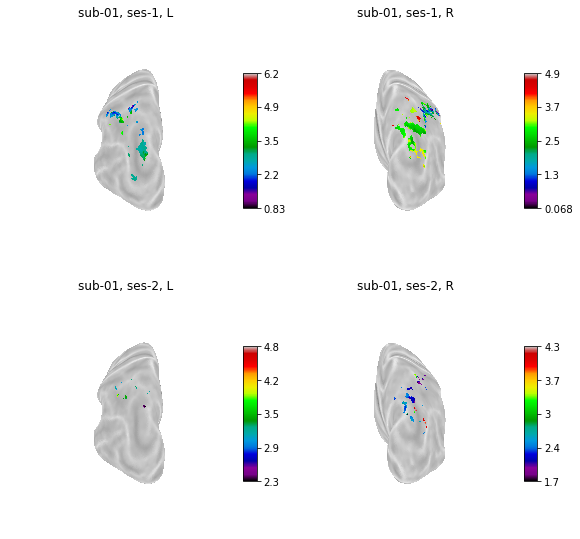

In [5]:
# example plot
sub = 1
fig, axs = plt.subplots(2, 2, figsize=(10, 10), subplot_kw={'projection': '3d'})
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i, ses in enumerate([1, 2]):
    for j,hemi in enumerate(['L', 'R']):
        ax = axs[i, j]
        title = f'sub-{sub:02d}, ses-{ses}, {hemi}'
        plot_surf_data(sub, ses,hemi=hemi, mask_by_ips=True, view='posterior', cmap='nipy_spectral', ax=ax)
        ax.set_title(title)

#plt.savefig(op.join(plot_im_folder,f'sub-{sub}.png'), dpi=300)

### Loop for images saving to 'plot_im_folder'

In [7]:
# Loop over all subjects

for sub in subList:
    filename = op.join(plot_im_folder,f'sub-{sub}.png')
    if not op.exists(filename):
        try:
            fig, axs = plt.subplots(2, 2, figsize=(10, 10), subplot_kw={'projection': '3d'})
            plt.subplots_adjust(wspace=0.01, hspace=0.01)
            for i, ses in enumerate([1, 2]):
                for j,hemi in enumerate(['L', 'R']):
                    ax = axs[i, j]
                    title = f'sub-{sub}, ses-{ses}, {hemi}'
                    plot_surf_data(int(sub),ses,ax=ax,hemi=hemi, mask_by_ips=True, view='posterior', cmap='nipy_spectral')
                    ax.set_title(title)
            plt.savefig(filename, dpi=300)
            plt.close()
        except:
            print(f'failed for sub-{sub}')
            plt.close()
            continue

encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed
encoding_model.denoise.retroicor.smoothed


In [10]:
import pandas as pd

bids_folder_local = '/Users/mrenke/data/ds-stressrisk'
df_wdec = pd.read_csv(op.join(bids_folder_local, 'interim_sum_data','within-ses-decod_r-sds.csv'))

df_wdec = df_wdec.set_index(['group','subject','session'])
df_wdec.head()

sds         r
group   subject session                    
control 1       1        0.297518  0.038720
        2       1        0.363510 -0.020221
                2        0.383693 -0.037180
stress  3       1        0.321775  0.040654
                2        0.363966  0.092999

#### rename files with group and r

In [ ]:
# rename files woth group and r
import os
# Set the directory where the images are stored
image_dir = plot_im_folder

# Iterate over the DataFrame
for index, row in df_wdec.reset_index().iterrows():
    subject = row['subject']
    subject = f'{subject:02d}'
    group = row['group']
    r = np.round(row['r'],2)
    
    old_filename = os.path.join(image_dir, f'sub-{subject}.png')
    new_filename = os.path.join(image_dir, f'sub-{subject}_{group}_r-{r}-.png')
    
    if os.path.exists(old_filename):
        os.rename(old_filename, new_filename)
    else:
        print(f'{old_filename} does not exist')

In [ ]:
# one fig with both hemis

def plot_surf_data(subject,ses,key = 'encoding_model.denoise.retroicor.smoothed',cmap='nipy_spectral',threshold = 0.05, colorbar=True, filter_extreme_prfs = True, mask_by_ips = False, view='posterior', darkness=0.5):
    fig = plt.figure(figsize=(10, 5))

    space = 'fsnative'
    sub = f'{subject:02d}'
    subject = Subject(subject, bids_folder = bids_folder)

    # prep surf data
    prf_pars = subject.get_prf_parameters_surf(ses, run=None,  key=key, nilearn=True, space=space)
    mask = (prf_pars['r2']  > threshold).values
    if filter_extreme_prfs:
        mask =  mask & (prf_pars['mu'] > 0).values & (prf_pars['mu'] < 28).values 
    if mask_by_ips:
        ips_mask = subject.get_surf_mask(roi='ips')
        mask = mask & ips_mask

    surf_data = prf_pars['mu'].values
    surf_data[~mask] = np.nan

    # left
    surf_data_half = surf_data[0:len_L]
    surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', 'lh.inflated') # this time use fasnative surf_mesh, not fsaver
    surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', 'lh.avg_curv') # this time use fasnative surf_mesh, not fsaver
    ax1 = fig.add_subplot(121, projection="3d")
    nplt.plot_surf(surf_mesh, surf_data_half, cmap=cmap, view=view, colorbar=colorbar, bg_map=surf_mesh_curv, bg_on_data=False, darkness=darkness, axes=ax1)

    #right
    surf_data_half = surf_data[len_L:]
    surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', 'rh.inflated') # this time use fasnative surf_mesh, not fsaver
    surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', 'rh.avg_curv') # this time use fasnative surf_mesh, not fsaver
    ax2 = fig.add_subplot(122, projection="3d")
    nplt.plot_surf(surf_mesh, surf_data_half, cmap=cmap, view=view, colorbar=colorbar, bg_map=surf_mesh_curv, bg_on_data=False, darkness=darkness, axes=ax2)
    return fig


## with GRADIENTS beneath

In [8]:
# check GM
from nilearn import surface

def plot_from_gii(sub, file, ax, space = 'fsnative',hemi='L',title = '',
                   view='posterior', darkness=0.5,colorbar=True, cmap='viridis'):
    sub = f'{subject:02d}'
    surf_data = surface.load_surf_data(file)

    hemi_fs = 'lh' if hemi == 'L' else 'rh'
    surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.inflated') # this time use fasnative surf_mesh, not fsaver
    surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.avg_curv') # this time use fasnative surf_mesh, not fsaver
    
    nplt.plot_surf(surf_mesh, surf_data, title=title,cmap=cmap, view=view, colorbar=colorbar, bg_map=surf_mesh_curv, bg_on_data=False, darkness=darkness, axes=ax)
    return ax

<Axes3DSubplot:>

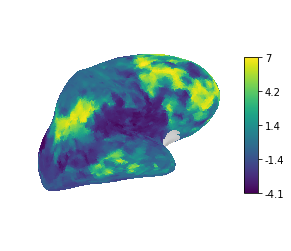

In [34]:
from nilearn import surface

subject = 1
sub = f'{subject:02d}'
hemi = 'R'
ses = 1
grad_n = 2
specification = '_reordMaskFlip'

file = op.join(f'sub-{sub}', f'ses-{ses}',  f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-{hemi}_grad{grad_n}{specification}.surf.gii')
fn = op.join(bids_folder,'derivatives/gradients',file)
#grad = surface.load_surf_data(fn)
#grad_rescaled = np.nan_to_num(grad) # replace NaNs with 0 otherwise bg_map is not plotted, (there were 8728 NaN values in the array for sub-01.)

fig, axs = plt.subplots(1,1, figsize=(5,5), subplot_kw={'projection': '3d'})
plot_from_gii(sub= sub,file=fn, ax=axs, hemi=hemi, view='medial')

In [32]:
subject = 17
sub = f'{subject:02d}'
hemi = 'R'
ses = 1
grad_n = 1
specification = '_reordMaskFlip'

file = op.join(f'sub-{sub}', f'ses-{ses}',  f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-{hemi}_grad{grad_n}{specification}.surf.gii')
fn = op.join(bids_folder,'derivatives/gradients',file)
grad = surface.load_surf_data(fn)
grad_rescaled = np.nan_to_num(grad)

space = 'fsnative'
threshold = 0.05
filter_extreme_prfs = True
mask_by_ips = True

subject = Subject(subject, bids_folder = bids_folder)

# prep surf data
prf_pars = subject.get_prf_parameters_surf(ses, run=None, hemi=hemi, key=key, nilearn=True, space=space)
mask = (prf_pars['r2']  > threshold).values
N_vertices_hemi = np.shape(prf_pars)[0]

if filter_extreme_prfs:
    mask =  mask & (prf_pars['mu'] > 0).values & (prf_pars['mu'] < 28).values 
if mask_by_ips:
    ips_mask = subject.get_surf_mask(roi='ips') #gets ips mask for both hemis
    ips_mask_half = ips_mask[:N_vertices_hemi] if hemi == 'L' else ips_mask[len(ips_mask) - N_vertices_hemi:]
    mask = mask & ips_mask_half

surf_data = prf_pars['mu'].values
surf_data[~mask] = np.nan
surf_data.shape

#surf_data_half = surf_data[0:len_L] if hemi == 'L' else surf_data[len_L:]
hemi_fs = 'lh' if hemi == 'L' else 'rh'
surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.inflated') # this time use fasnative surf_mesh, not fsaver
surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.avg_curv') # this time use fasnative surf_mesh, not fsaver


encoding_model.denoise.retroicor.smoothed


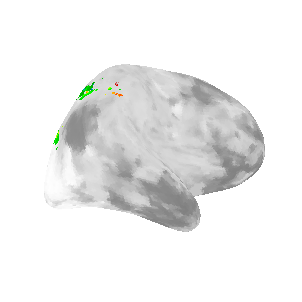

In [33]:
#now with gradient underneath

view = 'medial'
colorbar = True 
cmap = 'nipy_spectral'


nplt.plot_surf(surf_mesh, surf_data, bg_map=grad_rescaled,cmap=cmap, view=view, darkness=0.5 ,colorbar=False,bg_on_data=False,engine='matplotlib')
plt.show()

In [2]:
## loop for plots
# only ses 1
import pandas as pd 

plot_im_folder = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/nPRF-mu_r2-fil_GM-below_nplt_ses1'
bids_folder_local = '/Users/mrenke/data/ds-stressrisk'
df_wdec = pd.read_csv(op.join(bids_folder_local, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

In [10]:
def plot_nPRF_GMbelow(subject,ax,session=1, 
                      hemi='R', grad_n = 1, threshold = 0.05,
                      view='posterior', cmap='nipy_spectral'):
    
    sub = f'{subject:02d}'
    subject = Subject(subject, bids_folder = bids_folder)

    # nPRF: prep surf data
    prf_pars = subject.get_prf_parameters_surf(session, run=None, hemi=hemi, key=key, nilearn=True, space='fsnative')
    mask = (prf_pars['r2']  > threshold).values
    mask =  mask & (prf_pars['mu'] > 0).values & (prf_pars['mu'] < 28).values # filter_extreme_prfs
    # mask_by_ips = False for now,     N_vertices_hemi = np.shape(prf_pars)[0]
    surf_data = prf_pars['mu'].values
    surf_data[~mask] = np.nan

    # GM: gray pattern underneath, normally surf_mesh_curv, but now GM
    #surf_mesh_curv = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.avg_curv') # this time use fasnative surf_mesh, not fsaver
    grad_specification = '_reordMaskFlip'
    fn = op.join(bids_folder,'derivatives/gradients',f'sub-{sub}', f'ses-{session}',  f'sub-{sub}_ses-{session}_task-risk_space-fsnative_hemi-{hemi}_grad{grad_n}{grad_specification}.surf.gii')
    grad = np.nan_to_num(surface.load_surf_data(fn))

    hemi_fs = 'lh' if hemi == 'L' else 'rh'
    surf_mesh = op.join(bids_folder,'derivatives', 'freesurfer', f'sub-{sub}','surf', f'{hemi_fs}.inflated') # this time use fasnative surf_mesh, not fsaver
    nplt.plot_surf(surf_mesh, surf_data, bg_map=grad, title=title,cmap=cmap, view=view, colorbar=colorbar, bg_on_data=False, darkness=0.5, axes=ax)



NameError: name 'ses' is not defined

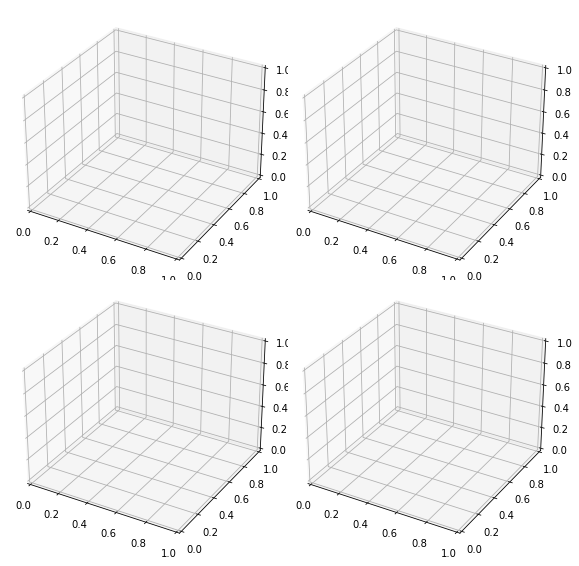

In [11]:
sub = subList[1]

decodability = df_wdec.xs(int(sub),0, level='subject').xs(1, level='session')['r'].values[0]
filename = op.join(plot_im_folder,f'sub-{sub}_r-{np.round(decodability,3)}.png')

fig, axs = plt.subplots(2, 2, figsize=(10, 10), subplot_kw={'projection': '3d'})
plt.subplots_adjust(wspace=0.01, hspace=0.01)
for i, grad_n in enumerate([1, 2]):
    for j,hemi in enumerate(['L', 'R']):
        ax = axs[i, j]
        if grad_n == 1:
            view = 'medial' if hemi == 'R' else 'lateral'
        else:
            view = 'posterior'

        title = f'sub-{sub}, {hemi}, grad{grad_n}'
        plot_nPRF_GMbelow(int(sub),ax=ax,hemi=hemi, view=view, grad_n=grad_n)
        ax.set_title(title)

#plt.savefig(filename, dpi=300)
#plt.close()

In [4]:
# do grad-2 posterior, grad-1 medial/lateral (for R/L respectively)

for sub in subList:
    decodability = df_wdec.xs(int(sub),0, level='subject').xs(1, level='session')['r'].values[0]
    filename = op.join(plot_im_folder,f'sub-{sub}_r-{np.round(decodability,3)}.png')
    if not op.exists(filename):
        try:

            fig, axs = plt.subplots(2, 2, figsize=(10, 10), subplot_kw={'projection': '3d'})
            plt.subplots_adjust(wspace=0.01, hspace=0.01)
            for i, grad_n in enumerate([1, 2]):
                for j,hemi in enumerate(['L', 'R']):
                    ax = axs[i, j]
                    if grad_n == 1:
                        view = 'medial' if hemi == 'R' else 'lateral'
                    else:
                        view = 'posterior'

                    title = f'sub-{sub}, {hemi}, grad{grad_n}'
                    plot_nPRF_GMbelow(int(sub),ax=ax,hemi=hemi, view=view, grad_n=grad_n)
                    ax.set_title(title)

            plt.savefig(filename, dpi=300)
            plt.close()
            print(f'sub-{sub} worked')
        except:
            print(f'failed for sub-{sub}')
            plt.close()
            continue

failed for sub-02
failed for sub-03
failed for sub-04
failed for sub-05
failed for sub-09
failed for sub-10
failed for sub-12
failed for sub-13
failed for sub-14
failed for sub-16
failed for sub-17
failed for sub-18
failed for sub-19
failed for sub-21
failed for sub-22
failed for sub-23
failed for sub-24
failed for sub-25
failed for sub-26
failed for sub-28
failed for sub-30
failed for sub-31
failed for sub-32
failed for sub-34
failed for sub-35
failed for sub-36
failed for sub-37
failed for sub-38
failed for sub-39
failed for sub-40
failed for sub-41
failed for sub-42
failed for sub-43
failed for sub-44
failed for sub-45
failed for sub-46
failed for sub-47
failed for sub-48
failed for sub-49
failed for sub-50
failed for sub-51
failed for sub-52
failed for sub-53
failed for sub-54
failed for sub-55
failed for sub-57
failed for sub-58
failed for sub-59
failed for sub-61


### plotting surfaces over each other

apparentlty does not work with nilearn.plotting.plot_surf()
but with 
import pyvista as pv

p = pv.Plotter()
p.add_mesh(mesh1, color="red")
p.add_mesh(mesh2, color="blue")

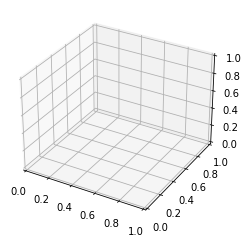

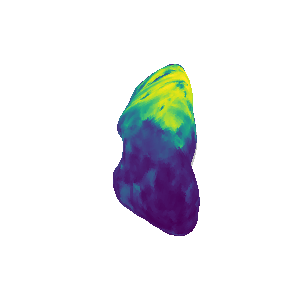

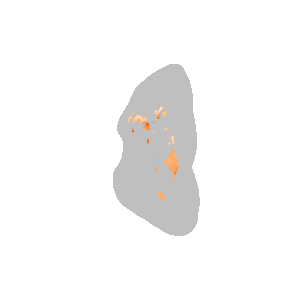

In [71]:
fig,ax = plt.subplots(1,1,subplot_kw={'projection': '3d'})

nplt.plot_surf(surf_mesh, grad, ax=ax,fig=fig,cmap='viridis', view=view, darkness=0.5 ,colorbar=False,bg_on_data=False,engine='matplotlib')
nplt.plot_surf(surf_mesh, surf_data, ax=ax,fig=fig,cmap='Oranges', view=view, darkness=0.5 ,colorbar=False,bg_on_data=False,engine='matplotlib')
plt.show()


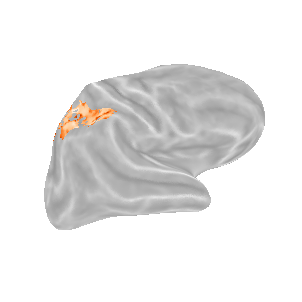

In [98]:
view = 'medial'
nplt.plot_surf(surf_mesh, surf_data,cmap='Oranges',bg_map=surf_mesh_curv, bg_on_data=False, view=view, darkness=0.5 ,colorbar=False,engine='matplotlib')
plt.show()